In [1]:
import pandas as pd
import os

# Define the path to Downloads folder (Overførsler)
path = r'C:\Users\Bruger\Downloads' 

# Load using the full path
loans = pd.read_csv(os.path.join(path, 'Final_loan_analysis.csv'))
customers = pd.read_csv(os.path.join(path, 'Final_customers.csv'))
branches = pd.read_csv(os.path.join(path, 'Final_branches.csv'))
accounts = pd.read_csv(os.path.join(path, 'Final_accounts.csv'))
transactions = pd.read_csv(os.path.join(path, 'Final_transactions.csv'))
addresses = pd.read_csv(os.path.join(path, 'Addresses.csv'))

print("Success! All files loaded.")
print(loans.head())

Success! All files loaded.
   LoanID  AccountID  LoanStatusID PrincipalAmount InterestRate  \
0  400230     200876             1        76958,56          547   
1  400307     200789             1        29013,67          321   
2  400233     201275             1        48596,76        1,017   
3  400100     200070             1         9191,43          999   
4  400141     200808             1        76322,83          906   

           StartDate    EstimatedEndDate  Duration_Days  \
0  20. November 2022      6. August 2026         1355.0   
1   22. februar 2022    8. December 2025         1385.0   
2  21. November 2021       30. juli 2023          616.0   
3    14. August 2021  18. September 2023          765.0   
4       4. juni 2021    23. oktober 2024         1237.0   

   PrincipalAmount (bins)  
0                   75000  
1                   25000  
2                   45000  
3                    5000  
4                   75000  


In [2]:
# Check columns in the main tables
print("Accounts Columns:", accounts.columns.tolist())
print("Transactions Columns:", transactions.columns.tolist())
print("Loans Columns:", loans.columns.tolist())

Accounts Columns: ['AccountID', 'CustomerID', 'AccountTypeID', 'AccountStatusID', 'Balance', 'OpeningDate']
Transactions Columns: ['TransactionID', 'AccountOriginID', 'AccountDestinationID', 'TransactionTypeID', 'Amount', 'TransactionDate', 'BranchID', 'Description', 'fraud_flag', 'avg_amount', 'is_spike', 'Amount (bins)']
Loans Columns: ['LoanID', 'AccountID', 'LoanStatusID', 'PrincipalAmount', 'InterestRate', 'StartDate', 'EstimatedEndDate', 'Duration_Days', 'PrincipalAmount (bins)']


In [5]:
## Predict Principal Amount (Regression) MLR
## Predictors (X): InterestRate, Duration_Days, and Balance.Target (y): PrincipalAmount

# 1. Merge as usual
df_combined = pd.merge(loans, accounts, on='AccountID', how='inner')

# 2. Function to fix the commas and convert to float
def fix_numbers(column):
    # Convert to string first, replace comma with dot, then convert to float
    return pd.to_numeric(column.astype(str).str.replace(',', '.'), errors='coerce')

# 3. Apply the fix to all numeric columns
df_combined['InterestRate'] = fix_numbers(df_combined['InterestRate'])
df_combined['Balance'] = fix_numbers(df_combined['Balance'])
df_combined['PrincipalAmount'] = fix_numbers(df_combined['PrincipalAmount'])
df_combined['Duration_Days'] = fix_numbers(df_combined['Duration_Days'])

# 4. Drop any rows that failed to convert (NaN)
df_combined = df_combined.dropna(subset=['InterestRate', 'Balance', 'PrincipalAmount'])

# 5. Now try the Regression selection
X = df_combined[['InterestRate', 'Duration_Days', 'Balance']]
y = df_combined['PrincipalAmount']

print("Data converted successfully! Ready for training.")

Data converted successfully! Ready for training.


In [7]:
# 1. Combine X and y into a temporary dataframe to drop rows together
# This ensures that if we drop a row in X, we also drop the same row in y
clean_df = df_combined[['InterestRate', 'Duration_Days', 'Balance', 'PrincipalAmount']].dropna()

# 2. Redefine X and y from the cleaned dataframe
X = clean_df[['InterestRate', 'Duration_Days', 'Balance']]
y = clean_df['PrincipalAmount']

# 3.  running the split and fit again
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

print("Success! The model has been fitted without NaN errors.")

Success! The model has been fitted without NaN errors.


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize and Fit the Model
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# 3. Make Predictions on the test set
y_pred = reg_model.predict(X_test)

# 4. Calculate Accuracy Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Training Complete!")
print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Model Training Complete!
R-squared: -0.0303
Mean Absolute Error (MAE): 20798.09
Root Mean Squared Error (RMSE): 24681.64


In [9]:
# Create a small table to see the importance of each predictor
# The Coefficients are the "weights" the model gives to each piece of information.
coeff_df = pd.DataFrame(reg_model.coef_, X.columns, columns=['Coefficient'])
print("\n--- Model Coefficients ---")
print(coeff_df)
print(f"Intercept: {reg_model.intercept_:.2f}")


--- Model Coefficients ---
               Coefficient
InterestRate      1.297044
Duration_Days    -3.711898
Balance          -0.000426
Intercept: 56057.76


In [10]:
## Classification: Predicting Loan Default

# 1. Create a binary target: 1 for Default, 0 for Safe
# Adjust the '1' if 'Active' status ID is different
df_combined['IsDefault'] = df_combined['LoanStatusID'].apply(lambda x: 1 if x > 1 else 0)

# 2. Check the "Class Balance" (How many defaults vs non-defaults)
print("Class Counts:")
print(df_combined['IsDefault'].value_counts())

Class Counts:
IsDefault
0    107
1     46
Name: count, dtype: int64


In [11]:
## Train the Decision Tree
## This model uses Recursive Binary Splitting to create a flowchart of risk.

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Define Features (X) and Target (y)
# I include PrincipalAmount here because larger loans might be riskier!
X_c = df_combined[['PrincipalAmount', 'InterestRate', 'Balance', 'Duration_Days']]
y_c = df_combined['IsDefault']

# 2. Split (80/20)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

# 3. Initialize and Fit (Max_depth=3 prevents overfitting)
clf_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_tree.fit(X_train_c, y_train_c)

# 4. Predict
y_pred_c = clf_tree.predict(X_test_c)

# 5. Results
print(f" Classification Accuracy: {accuracy_score(y_test_c, y_pred_c)*100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_c))


 Classification Accuracy: 77.42%

Confusion Matrix:
[[23  0]
 [ 7  1]]


In [12]:
from sklearn.tree import export_text
tree_rules = export_text(clf_tree, feature_names=list(X_c.columns))
print(tree_rules)

|--- PrincipalAmount <= 11145.61
|   |--- class: 0
|--- PrincipalAmount >  11145.61
|   |--- PrincipalAmount <= 17168.83
|   |   |--- class: 1
|   |--- PrincipalAmount >  17168.83
|   |   |--- Duration_Days <= 1393.00
|   |   |   |--- class: 0
|   |   |--- Duration_Days >  1393.00
|   |   |   |--- class: 0



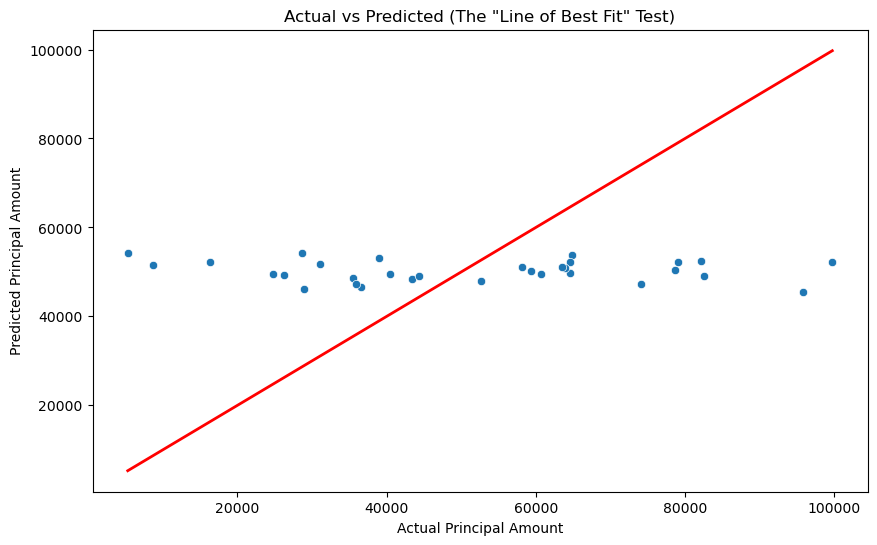

In [13]:
## Visualize Line of Best Fit
# The "Actual vs. Predicted" Plot MLR

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2) # The "Perfect" line
plt.xlabel('Actual Principal Amount')
plt.ylabel('Predicted Principal Amount')
plt.title('Actual vs Predicted (The "Line of Best Fit" Test)')
plt.show()



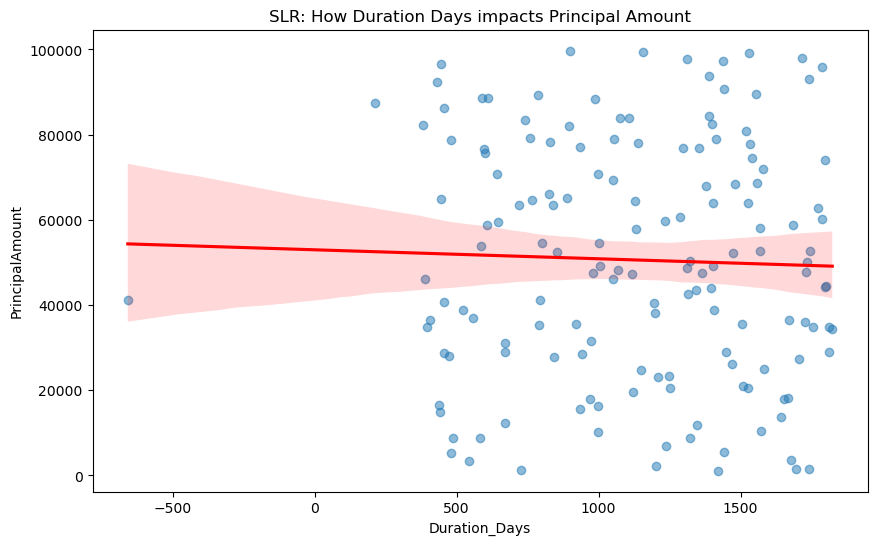

In [14]:
# Simple Regression Visuals (SLR)

plt.figure(figsize=(10, 6))
sns.regplot(x='Duration_Days', y='PrincipalAmount', data=df_combined, 
            line_kws={"color": "red"}, scatter_kws={"alpha": 0.5})
plt.title('SLR: How Duration Days impacts Principal Amount')
plt.show()

In [16]:
# Fix the above line. Aggregating Transaction Data

# 1. Group transactions by AccountID to get a single 'Customer Profile'
trans_agg = transactions.groupby('AccountOriginID')['Amount'].mean().reset_index()
trans_agg.columns = ['AccountID', 'Avg_Transaction_Size']

# 2. Merge this NEW feature into the main dataset
df_fixed = pd.merge(df_combined, trans_agg, on='AccountID', how='inner')

# 3. Clean the new column (just in case of commas/NaNs)
df_fixed['Avg_Transaction_Size'] = pd.to_numeric(df_fixed['Avg_Transaction_Size'].astype(str).str.replace(',', '.'), errors='coerce')
df_fixed = df_fixed.dropna(subset=['Avg_Transaction_Size'])

print("New Feature 'Avg_Transaction_Size' added!")

New Feature 'Avg_Transaction_Size' added!


In [19]:
# Re-running the regression with the new feature 

# 1. Define the list of columns to use
features = ['InterestRate', 'Duration_Days', 'Balance', 'Avg_Transaction_Size']
target = 'PrincipalAmount'

# 2. Drop ANY row that has a NaN in these specific columns
# This ensures X and y are perfectly aligned and clean
df_model_ready = df_fixed.dropna(subset=features + [target])

# 3. Final check - this should print 0
print(f"NaNs remaining: {df_model_ready[features].isna().sum().sum()}")

# 4. Redefine X and y from the CLEANED dataframe
X_fixed = df_model_ready[features]
y_fixed = df_model_ready[target]

# 5. Split and Train
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_fixed, y_fixed, test_size=0.2, random_state=42)

model_fixed = LinearRegression()
model_fixed.fit(X_train_f, y_train_f)

# 6. Evaluation
y_pred_f = model_fixed.predict(X_test_f)
print(f" New R-squared: {r2_score(y_test_f, y_pred_f):.4f}")

NaNs remaining: 0
 New R-squared: -0.1668


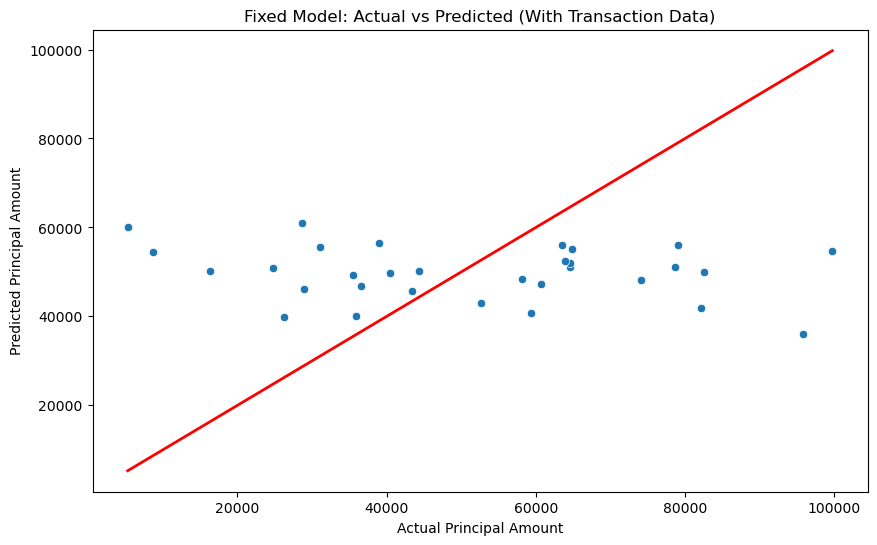

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Plotting the new predictions against the actual values
sns.scatterplot(x=y_test_f, y=y_pred_f)

# The "Perfect Prediction" Line
plt.plot([y_test_f.min(), y_test_f.max()], [y_test_f.min(), y_test_f.max()], color='red', lw=2)

plt.xlabel('Actual Principal Amount')
plt.ylabel('Predicted Principal Amount')
plt.title('Fixed Model: Actual vs Predicted (With Transaction Data)')
plt.show()

In [21]:
## VIF (Multicollinearity)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# We only check the features (X)
X_vif = df_model_ready[['InterestRate', 'Duration_Days', 'Balance', 'Avg_Transaction_Size']]

# Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("--- VIF Results ---")
print(vif_data)

--- VIF Results ---
                feature       VIF
0          InterestRate  1.908232
1         Duration_Days  6.498587
2               Balance  3.086224
3  Avg_Transaction_Size  8.701182


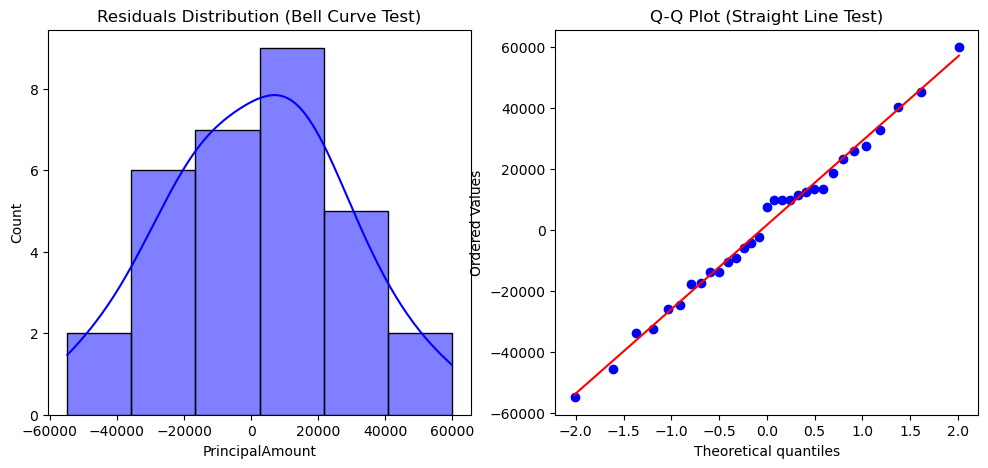

In [22]:
## Checking Normality of Residuals

import scipy.stats as stats

# Calculate Residuals (Actual - Predicted)
residuals = y_test_f - y_pred_f

plt.figure(figsize=(12, 5))

# Plot 1: Histogram
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='blue')
plt.title('Residuals Distribution (Bell Curve Test)')

# Plot 2: Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot (Straight Line Test)')

plt.show()

In [23]:
# Feature Selection: Lasso vs. Ridge

from sklearn.linear_model import Ridge, Lasso

# 1. Ridge Regression
ridge_reg = Ridge(alpha=1.0) # alpha is the 'penalty' strength
ridge_reg.fit(X_train_f, y_train_f)
print(f"Ridge R-squared: {ridge_reg.score(X_test_f, y_test_f):.4f}")

# 2. Lasso Regression
lasso_reg = Lasso(alpha=1.0)
lasso_reg.fit(X_train_f, y_train_f)
print(f"Lasso R-squared: {lasso_reg.score(X_test_f, y_test_f):.4f}")

# Looking at Lasso coefficients to see if it "killed" any variables
print("\nLasso Coefficients:")
print(pd.Series(lasso_reg.coef_, index=X_fixed.columns))

Ridge R-squared: -0.1668
Lasso R-squared: -0.1668

Lasso Coefficients:
InterestRate            3.405842
Duration_Days          -4.209812
Balance                -0.000583
Avg_Transaction_Size    0.168138
dtype: float64


In [25]:
## Decision trees Train Tree

from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Define Features (Adding our new Transaction Habit variable)
features_tree = ['PrincipalAmount', 'InterestRate', 'Balance', 'Duration_Days', 'Avg_Transaction_Size']
X_tree = df_model_ready[features_tree]
y_tree = df_model_ready['IsDefault']

# 2. Split train test (80/20)
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_tree, y_tree, test_size=0.2, random_state=42)

# 3. Initialize with 'Entropy' (measures the "chaos" in the data)
dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
dt_model.fit(X_train_t, y_train_t)

# 4. Results
y_pred_t = dt_model.predict(X_test_t)
print(f" Refined Tree Accuracy: {accuracy_score(y_test_t, y_pred_t)*100:.2f}%")


 Refined Tree Accuracy: 61.29%


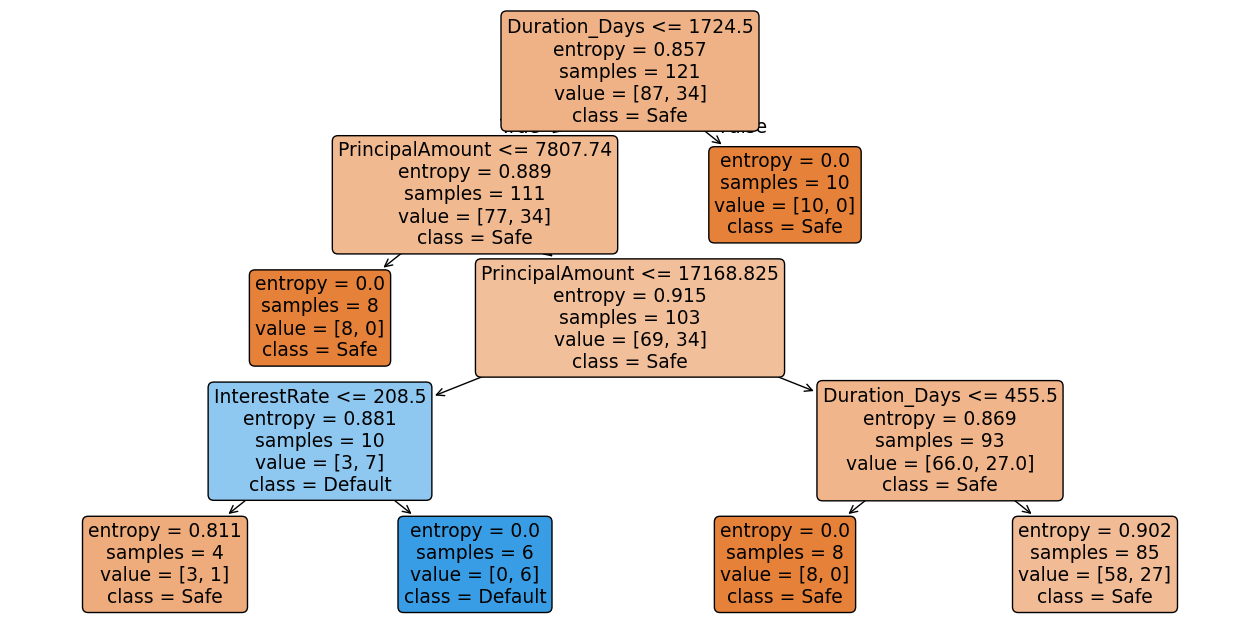

In [28]:
plt.figure(figsize=(16,8))
plot_tree(dt_model, feature_names=features_tree, class_names=['Safe', 'Default'], filled=True, rounded=True)
plt.show()

 Random Forest Accuracy: 64.52%

Detailed Report:
              precision    recall  f1-score   support

           0       0.66      0.95      0.78        20
           1       0.50      0.09      0.15        11

    accuracy                           0.65        31
   macro avg       0.58      0.52      0.46        31
weighted avg       0.60      0.65      0.55        31



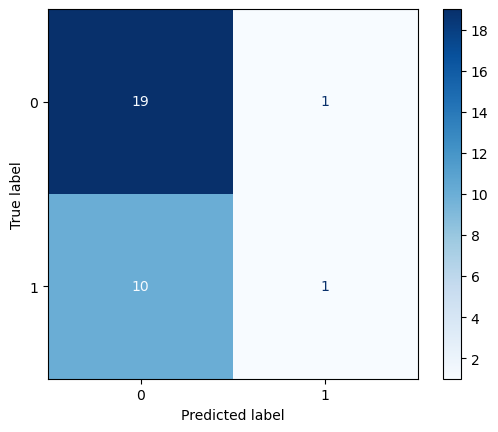

In [30]:
## Building the Random Forest, confusion matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# 1. Initialize the Forest (n_estimators = number of trees)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 2. Fit the model
rf_model.fit(X_train_t, y_train_t)

# 3. Predict
y_pred_rf = rf_model.predict(X_test_t)

# 4. Accuracy & Report
print(f" Random Forest Accuracy: {accuracy_score(y_test_t, y_pred_rf)*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test_t, y_pred_rf))

# 5. Visualizing the Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf_model, X_test_t, y_test_t, cmap='Blues')
plt.show()

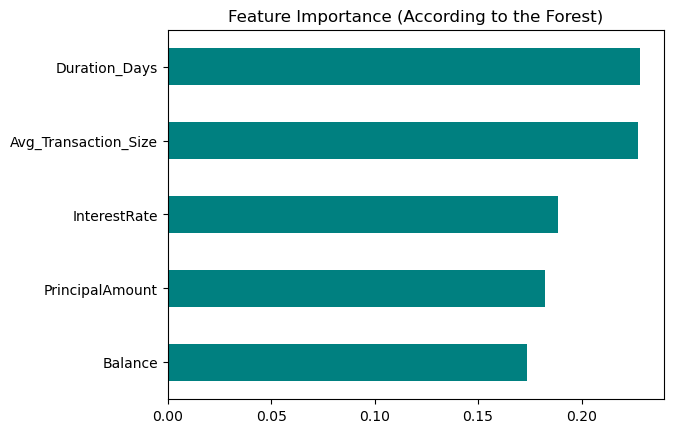

In [31]:
# Checking the most valuable features

import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=features_tree)
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance (According to the Forest)')
plt.show()

In [34]:
## MODEL DEPLOYMENT
# Saving the Model (The "Export")

import joblib

# Saving the trained model to a file
joblib.dump(rf_model, 'loan_default_forest_model.pkl')

# IMPORTANT: saving feature list/scaler if there is any used
# so that the "deployed" version knows exactly what inputs to expect.
joblib.dump(features_tree, 'model_features.pkl')

print("Model successfully serialized and saved!")

Model successfully serialized and saved!


In [35]:
# Loading the Model (The "Deployment")

# In a new script or a web app:
loaded_rf = joblib.load('loan_default_forest_model.pkl')

# Now we can predict on a brand-new customer immediately:
# new_customer = [[PrincipalAmount, InterestRate, Balance, Duration, Avg_Trans]]
prediction = loaded_rf.predict([[25000, 15.5, 5000, 365, 450]])

print(f"Risk Assessment: {'Default' if prediction[0] == 1 else 'Safe'}")

Risk Assessment: Safe


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [36]:
# Building the All-in-One Pipeline

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. The steps in our "Factory"
pipeline_steps = [
    ('imputer', SimpleImputer(strategy='median')), # Automatically fills NaNs with the median
    ('scaler', StandardScaler()),                 # Centers and scales the data
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42))
]

# 2. Create the Pipeline object
loan_pipeline = Pipeline(steps=pipeline_steps)

# 3. Train the entire pipeline, cleans AND learns in one go
loan_pipeline.fit(X_train_t, y_train_t)

# 4. Save the ENTIRE factory
import joblib
joblib.dump(loan_pipeline, 'danish_bank_risk_pipeline.pkl')

print("Pipeline created, trained, and exported!")

Pipeline created, trained, and exported!
